# Exploratory Data Analysis (EDA) Dataset NusantaraLens
Analisis dataset gambar budaya Indonesia untuk keperluan klasifikasi multi-kelas.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
dataset_path = '/content/drive/MyDrive/Dataset_Sampel Gambar_Nusantaralens'

## Struktur Dataset
Melakukan inspeksi awal terhadap struktur folder dataset untuk memastikan dataset tersusun sesuai kategori dan kelas yang diharapkan.

In [8]:
import os
os.listdir(dataset_path)

['Kuliner', 'Lagu Daerah', 'Pahlawan Nasional', 'Tarian']

### Insight
Dataset terdiri atas empat kategori utama, yaitu Kuliner, Lagu Daerah, Pahlawan Nasional, dan Tarian. Struktur ini menunjukkan bahwa dataset menggunakan pendekatan hierarchical labeling sebelum dipisah ke kelas final.


## Analisis Jumlah Data per Kategori Utama
Menghitung jumlah subfolder/kelas pada masing-masing kategori utama untuk memahami struktur distribusi dataset pada level hierarki pertama.

In [9]:
class_counts = {}

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

print(class_counts)

{'Kuliner': 9, 'Lagu Daerah': 9, 'Pahlawan Nasional': 9, 'Tarian': 9}


### Insight
Setiap kategori utama pada dataset terdiri atas 9 subkelas, sehingga total kategori budaya yang tersedia dalam dataset berada dalam distribusi yang seimbang pada level hierarki pertama.

## Identifikasi Subkelas per Kategori
Menampilkan daftar subkelas pada setiap kategori utama untuk memahami label akhir yang akan digunakan dalam proses klasifikasi.

In [11]:
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        print(f"\n{category}:")
        print(os.listdir(category_path))


Kuliner:
['Gudeg', 'Sate_Klatak', 'Mie_Aceh', 'Eungkot_Keumamah', 'Ayam_Tangkap', 'Ikan_Kuah_Belimbing', 'Jagung_Bose', 'Daging_Belacang', 'Krecek']

Lagu Daerah:
['Kidang_Talun', 'Caping_Gunung', 'Suwe_Ora_Jamu', 'Tawar_Sedenge', 'Bungong_Jeumpa', 'Lembah_Alas', 'Anak_Kambing_Saya', 'Gemu_Fa_Mi_Re', 'Potong_Bebek_Angsa']

Pahlawan Nasional:
['Sultan_Hamengkubuwono_IX', 'Pangeran_Diponegoro', 'K.H._Ahmad_Dahlan', 'Cut_Nyak_Dhien', 'Teuku_Umar', 'Cut_Nyak_Meutia', 'Prof._Dr._Wilhelmus_Zakaria_Johannes', 'Izaak_Huru_Doko', 'Prof._Dr._Ir._Herman_Johannes']

Tarian:
['Tari_Srimpi', 'Tari_Klana_Alus', 'Tari_Bedhaya_Semang', 'Tari_Saman', 'Tari_Seudati', 'Tari_Likok_Pulo', 'Tari_Cerana', 'Tari_Caci', 'Tari_Danding']


### Insight
Setiap kategori utama terdiri atas 9 subkelas spesifik yang merepresentasikan objek budaya Indonesia. Dengan demikian, total kelas final dalam dataset adalah 36 kelas.

## Analisis Distribusi Jumlah Gambar per Kelas Final
Menghitung jumlah citra pada setiap kelas final untuk mengetahui distribusi data aktual yang akan digunakan dalam proses pelatihan model.

In [12]:
final_class_counts = {}

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        for subclass in os.listdir(category_path):
            subclass_path = os.path.join(category_path, subclass)

            if os.path.isdir(subclass_path):
                final_class_counts[subclass] = len(os.listdir(subclass_path))

print(final_class_counts)
print("Total kelas:", len(final_class_counts))

{'Gudeg': 58, 'Sate_Klatak': 30, 'Mie_Aceh': 40, 'Eungkot_Keumamah': 41, 'Ayam_Tangkap': 61, 'Ikan_Kuah_Belimbing': 31, 'Jagung_Bose': 37, 'Daging_Belacang': 30, 'Krecek': 47, 'Kidang_Talun': 39, 'Caping_Gunung': 45, 'Suwe_Ora_Jamu': 27, 'Tawar_Sedenge': 45, 'Bungong_Jeumpa': 25, 'Lembah_Alas': 30, 'Anak_Kambing_Saya': 54, 'Gemu_Fa_Mi_Re': 30, 'Potong_Bebek_Angsa': 28, 'Sultan_Hamengkubuwono_IX': 29, 'Pangeran_Diponegoro': 26, 'K.H._Ahmad_Dahlan': 24, 'Cut_Nyak_Dhien': 21, 'Teuku_Umar': 30, 'Cut_Nyak_Meutia': 30, 'Prof._Dr._Wilhelmus_Zakaria_Johannes': 23, 'Izaak_Huru_Doko': 23, 'Prof._Dr._Ir._Herman_Johannes': 22, 'Tari_Srimpi': 29, 'Tari_Klana_Alus': 28, 'Tari_Bedhaya_Semang': 36, 'Tari_Saman': 54, 'Tari_Seudati': 48, 'Tari_Likok_Pulo': 26, 'Tari_Cerana': 26, 'Tari_Caci': 55, 'Tari_Danding': 27}
Total kelas: 36


### Insight
Dataset memiliki total 36 kelas final dengan jumlah gambar per kelas berkisar antara 21 hingga 61 citra. Distribusi data tergolong cukup seimbang meskipun terdapat ketidakseimbangan ringan antar beberapa kelas.

## Analisis Resolusi Gambar
Menganalisis variasi ukuran/resolusi citra pada dataset untuk mengetahui tingkat homogenitas dimensi gambar sebelum tahap preprocessing.

In [13]:
from PIL import Image

sizes = []

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    for subclass in os.listdir(category_path):
        subclass_path = os.path.join(category_path, subclass)

        for img_name in os.listdir(subclass_path):
            img_path = os.path.join(subclass_path, img_name)

            try:
                img = Image.open(img_path)
                sizes.append(img.size)
            except:
                pass

print("Jumlah resolusi unik:", len(set(sizes)))
print("Contoh resolusi:", list(set(sizes))[:10])

Jumlah resolusi unik: 338
Contoh resolusi: [(613, 321), (583, 716), (747, 339), (750, 1000), (500, 300), (1200, 800), (1001, 600), (1006, 953), (1300, 1134), (1300, 1390)]


### Insight
Dataset memiliki variasi resolusi yang tinggi dengan 338 ukuran gambar unik. Hal ini menunjukkan bahwa dimensi citra tidak seragam sehingga diperlukan preprocessing berupa resizing ke ukuran tetap sebelum pelatihan model.

## Pemeriksaan Integritas File Gambar
Melakukan pengecekan terhadap seluruh file gambar untuk memastikan tidak terdapat file corrupt atau rusak yang dapat mengganggu proses training model.

In [14]:
corrupt_files = []

for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)

    for subclass in os.listdir(category_path):
        subclass_path = os.path.join(category_path, subclass)

        for img_name in os.listdir(subclass_path):
            img_path = os.path.join(subclass_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except:
                corrupt_files.append(img_path)

print("Jumlah file corrupt:", len(corrupt_files))

Jumlah file corrupt: 0


### Insight
Hasil pemeriksaan menunjukkan tidak ditemukan file gambar corrupt pada dataset. Dengan demikian, seluruh citra dinilai valid dan layak digunakan pada proses pelatihan model.

## Visualisasi Distribusi Data per Kelas
Menampilkan distribusi jumlah gambar pada setiap kelas final dalam bentuk diagram batang untuk mempermudah analisis keseimbangan dataset.

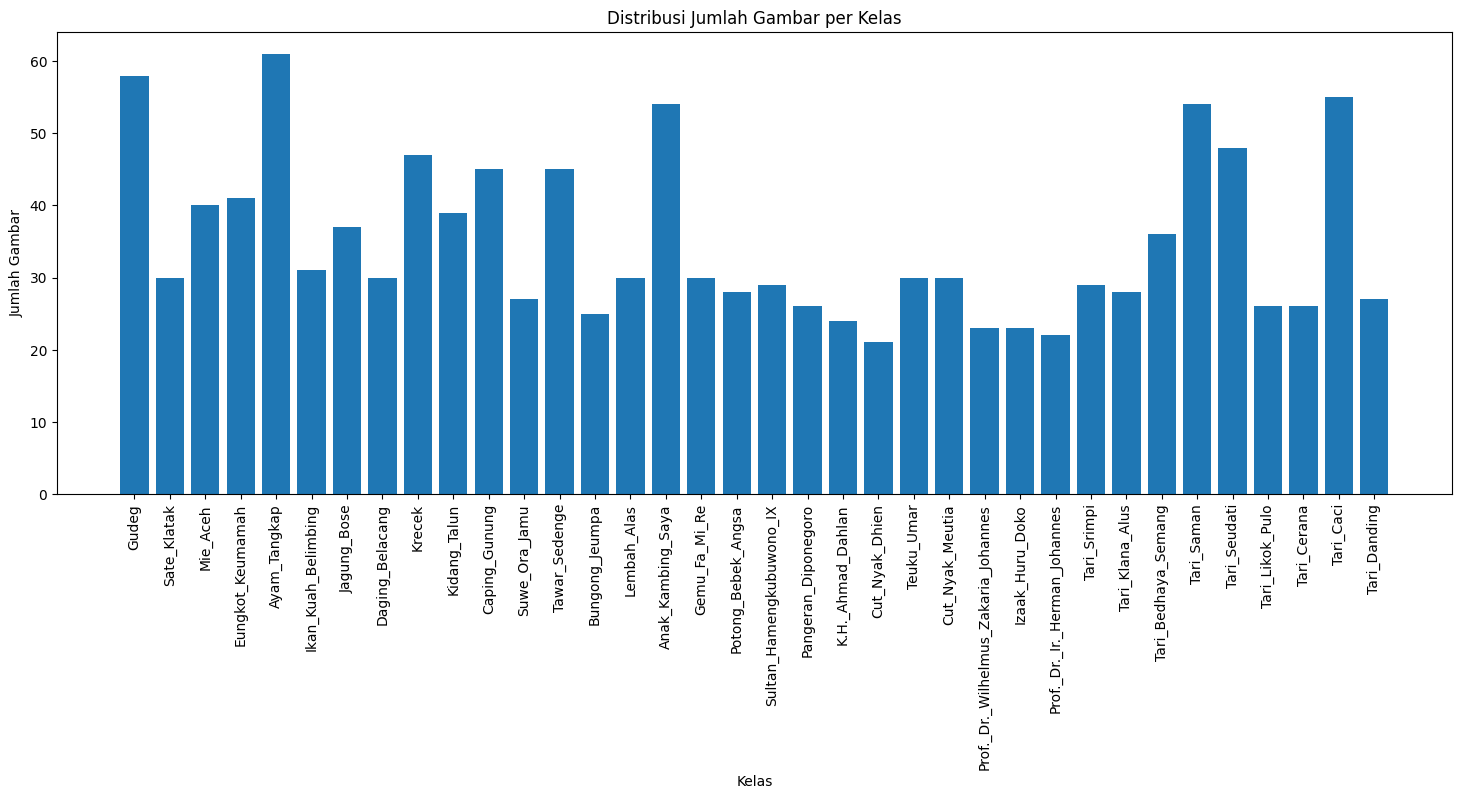

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))
plt.bar(final_class_counts.keys(), final_class_counts.values())
plt.xticks(rotation=90)
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.show()

### Insight
Visualisasi distribusi menunjukkan bahwa jumlah data antar kelas relatif merata, meskipun terdapat ketidakseimbangan ringan pada beberapa kelas. Ketidakseimbangan ini masih dalam batas wajar dan dapat ditangani melalui augmentasi data bila diperlukan.

## Visualisasi Distribusi Resolusi Gambar
Menampilkan persebaran dimensi lebar dan tinggi citra untuk memahami variasi ukuran gambar dalam dataset.

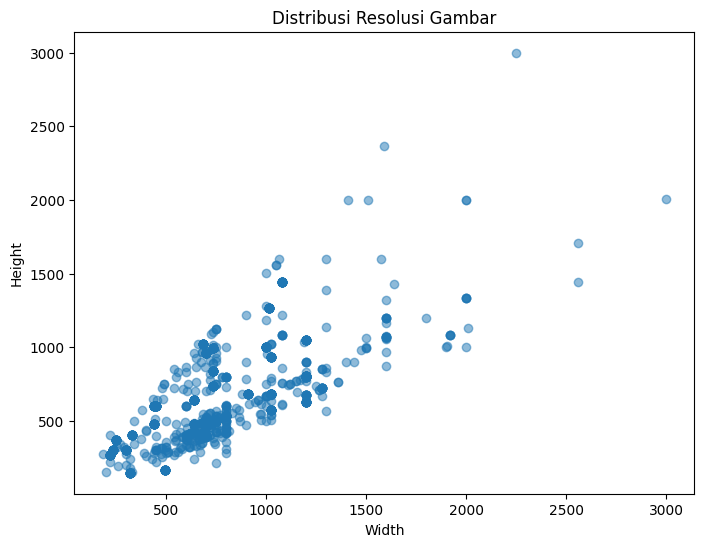

In [16]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(8,6))
plt.scatter(widths, heights, alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribusi Resolusi Gambar")
plt.show()

### Insight
Distribusi resolusi gambar menunjukkan variasi dimensi yang cukup tinggi baik pada lebar maupun tinggi citra. Hal ini mengindikasikan bahwa seluruh gambar perlu diseragamkan ukurannya melalui proses resizing sebelum digunakan dalam pelatihan model.

## Visualisasi Sampel Gambar Dataset
Menampilkan contoh citra dari beberapa kelas untuk melakukan inspeksi visual terhadap kualitas data, variasi objek, dan kesesuaian label.

In [17]:
import random
from PIL import Image

plt.figure(figsize=(15,15))

all_classes = list(final_class_counts.keys())[:9]

for i, cls in enumerate(all_classes):
    found = False
    for category in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, category, cls)

        if os.path.exists(class_path):
            img_name = random.choice(os.listdir(class_path))
            img_path = os.path.join(class_path, img_name)

            img = Image.open(img_path)

            plt.subplot(3,3,i+1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
            found = True
            break

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Visualisasi Sampel Gambar Dataset
Menampilkan contoh citra dari beberapa kelas untuk melakukan inspeksi visual terhadap kualitas data, variasi objek, dan kesesuaian label.